# 12 - Dataset to Downstream Workflow

**Current surface:** V0.29.

This tutorial is the end-to-end data-readiness recipe: start from an `xarray.Dataset`, run Dataset readiness, convert one scalar variable to `FieldBatch`, preflight the residual path, form a generator confidence report, and package downstream discovery evidence.

## What you will learn

- How to inspect a Dataset without inferring PDE identity.
- How to convert one explicit scalar variable into canonical `FieldBatch` form.
- How readiness, residual preflight, confidence, and downstream workflow summaries compose.
- How to read the supportability result without treating it as a benchmark claim.

## Required extras

Use `.[test]` or install `.[xarray]` and `.[viz]` for the Dataset and plotting portions.

## Expected runtime

Less than one minute on a laptop.

## Limitations

No file loaders, broad adapters, metadata inference, multidimensional grids, nonuniform grids, new PDEs, or new runtime APIs are introduced here.


In [1]:
from __future__ import annotations

from copy import deepcopy
import json

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from pdelie.data import from_xarray_dataset, generate_heat_1d_field_batch, split_batch_train_heldout
from pdelie.derivatives import compute_spectral_fd_derivatives
from pdelie.discovery import summarize_discovery_bridge_output, summarize_discovery_result, to_pysindy_trajectories
from pdelie.reporting import (
    summarize_downstream_discovery_workflow,
    summarize_field_batch_readiness,
    summarize_generator_confidence,
    summarize_generator_fit_diagnostics,
    summarize_residual_batch,
    summarize_verification_report,
    summarize_xarray_dataset_readiness,
)
from pdelie.residuals import HeatResidualEvaluator
from pdelie.symmetry import fit_translation_generator
from pdelie.verification import verify_translation_generator


def compact(report, keys):
    return {key: report[key] for key in keys}


In [2]:
source = generate_heat_1d_field_batch(batch_size=6, num_times=33, num_points=64, seed=29012)
metadata = deepcopy(source.metadata)
metadata["parameter_tags"]["equation"] = "heat_1d"

dataset = xr.Dataset(
    {"u": (source.dims, source.values)},
    coords={"time": source.coords["time"], "x": source.coords["x"]},
    attrs={"source": "tutorial-v0.29", "note": "attrs are reported, not canonical metadata"},
)

readiness = summarize_xarray_dataset_readiness(dataset, data_var="u", metadata=metadata, expected_equation="heat_1d")
field = from_xarray_dataset(dataset, data_var="u", var_name="u", metadata=metadata, preprocess_log=[{"operation": "tutorial_dataset_source"}])

print(json.dumps(compact(readiness, ["summary_type", "readiness_label", "selected_data_var", "candidate_variables"]), indent=2))
print("FieldBatch shape:", field.values.shape)
print("Preprocess operations:", [entry["operation"] for entry in field.preprocess_log])


{
  "summary_type": "xarray_dataset_readiness",
  "readiness_label": "ready",
  "selected_data_var": "u",
  "candidate_variables": [
    {
      "name": "u",
      "dims": [
        "batch",
        "time",
        "x",
        "var"
      ],
      "shape": [
        6,
        33,
        64,
        1
      ],
      "dtype": "float64",
      "numeric": true,
      "finite": true,
      "boolean_mask_like": false,
      "mask_candidate": false,
      "compatible": true,
      "failures": []
    }
  ]
}
FieldBatch shape: (6, 33, 64, 1)
Preprocess operations: ['tutorial_dataset_source', 'from_xarray_dataset', 'from_xarray']


In [3]:
evaluator = HeatResidualEvaluator()
train, heldout = split_batch_train_heldout(field, train_size=3, seed=29013)
field_readiness = summarize_field_batch_readiness(train, residual_evaluator=evaluator, expected_equation="heat_1d")
derivatives = compute_spectral_fd_derivatives(train)
residual = evaluator.evaluate(train, derivatives)
generator = fit_translation_generator(train, evaluator, epsilon=1e-4)
verification = verify_translation_generator(heldout, generator, evaluator)
confidence = summarize_generator_confidence(
    residual=summarize_residual_batch(residual),
    generator=generator,
    fit_diagnostics=summarize_generator_fit_diagnostics(generator),
    verification=summarize_verification_report(verification),
    thresholds={"residual_rms": 1e-5, "verification_first_error": 5e-4},
)

print(json.dumps({
    "field_readiness": field_readiness["readiness_label"],
    "residual_rms": confidence["residual"]["rms_residual"],
    "fit_evidence": confidence["fit_diagnostics"]["evidence_label"],
    "verification": confidence["verification"]["classification"],
    "confidence": confidence["confidence_label"],
}, indent=2))


{
  "field_readiness": "ready",
  "residual_rms": 1.0601002183749474e-05,
  "fit_evidence": "direct_svd_in_tolerance",
  "verification": "exact",
  "confidence": "failed"
}


In [4]:
trajectories, time_values, feature_names = to_pysindy_trajectories(train)
bridge = summarize_discovery_bridge_output(
    trajectories,
    time_values,
    feature_names,
    source_field_id="tutorial-heat-train-field",
    provenance={"workflow": "dataset_to_downstream", "release": "v0.29"},
)
manual_result = summarize_discovery_result(
    {
        "status": "success",
        "backend": "manual_backend_neutral",
        "feature_names": ["u"],
        "library_feature_names": ["u_xx"],
        "coefficients": [[0.1]],
        "equation_terms": {"u": {"u_xx": 0.1}},
        "equation_strings": {"u": "0.1*u_xx"},
        "fit_diagnostics": {"purpose": "tutorial_contract_summary_not_backend_benchmark"},
    },
    target_terms={"u": {"u_xx": 0.1}},
    source_result_id="manual-heat-reference",
)
workflow = summarize_downstream_discovery_workflow(
    field_readiness=field_readiness,
    generator_confidence=confidence,
    discovery_inputs=bridge,
    discovery_result=manual_result,
    extra_metrics={"workflow_recipe": "dataset_to_downstream", "release": "v0.29"},
)

print(json.dumps({
    "bridge": compact(bridge, ["summary_type", "trajectory_count", "num_state_features", "num_times"]),
    "recovery": manual_result["recovery"]["by_feature"]["u"]["classification"],
    "workflow_label": workflow["workflow_label"],
    "missing_evidence": workflow["missing_evidence"],
}, indent=2))


{
  "bridge": {
    "summary_type": "discovery_bridge_output",
    "trajectory_count": 3,
    "num_state_features": 64,
    "num_times": 33
  },
  "recovery": "exact",
  "workflow_label": "failed",
  "missing_evidence": [
    "orbit_provenance",
    "split_provenance"
  ]
}


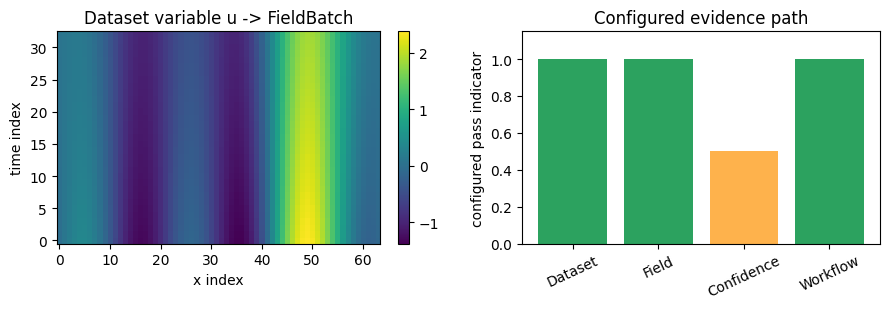

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
image = axes[0].imshow(field.values[0, :, :, 0], aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Dataset variable u -> FieldBatch")
axes[0].set_xlabel("x index")
axes[0].set_ylabel("time index")
fig.colorbar(image, ax=axes[0], fraction=0.046)

labels = ["Dataset", "Field", "Confidence", "Workflow"]
status_values = [1, 1, 1 if confidence["confidence_label"] == "strong" else 0.5, 1]
colors = ["#2ca25f" if value == 1 else "#feb24c" for value in status_values]
axes[1].bar(labels, status_values, color=colors)
axes[1].set_ylim(0, 1.15)
axes[1].set_title("Configured evidence path")
axes[1].set_ylabel("configured pass indicator")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()


## Takeaway

The V0.29 recipe does not add a new helper. It shows how existing Dataset readiness, `FieldBatch` readiness, residual preflight, generator confidence, and downstream discovery summaries already compose into a defensible workflow.
